# Análise Temporal de NFSe - Planejamento de Infraestrutura

## Objetivo
Análise temporal completa dos padrões de processamento de NFSe para planejamento de infraestrutura, com foco em:
1. **Evolução mensal**: Identificar sazonalidade e picos mensais
2. **Padrões semanais**: Dias da semana com maior/menor carga
3. **Padrões diários**: Horários de pico para dimensionamento
4. **Tendências futuras**: Projeções para 2026 (obrigatoriedade nacional)

## Contexto Regulatório
**2026**: Todos os municípios brasileiros serão obrigados a compartilhar NFSe com o ambiente nacional.

## Dados
- **Fonte**: `consulta_analise_picos_processamento_nfse.sql`
- **Campos principais**: `fb001_dtproc`, `fb001_hrproc`
- **Período**: Histórico completo disponível


In [1]:
# Verificar e instalar dependências se necessário
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Lista de pacotes necessários
packages = ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']

for package in packages:
    try:
        __import__(package)
        print(f"✅ {package} já instalado")
    except ImportError:
        print(f"📦 Instalando {package}...")
        install_package(package)
        print(f"✅ {package} instalado com sucesso")


📦 Instalando scikit-learn...
✅ scikit-learn instalado com sucesso
✅ pandas já instalado
✅ numpy já instalado
✅ matplotlib já instalado


c:\Users\94512868372\Anaconda3\envs\pandas-course\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy.stats import gaussian_kde


✅ seaborn já instalado


In [2]:
# Importações e configurações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Carregar dados
df = pd.read_csv('volumetria-data.csv')

# Conversões e preparação inicial
df['data_processamento'] = pd.to_datetime(df['data_processamento'])
df['ano'] = df['data_processamento'].dt.year
df['mes'] = df['data_processamento'].dt.month
df['dia'] = df['data_processamento'].dt.day
df['dia_semana'] = df['data_processamento'].dt.dayofweek  # 0=segunda, 6=domingo
df['semana_ano'] = df['data_processamento'].dt.isocalendar().week
df['trimestre'] = df['data_processamento'].dt.quarter
df['mes_ano'] = df['data_processamento'].dt.to_period('M')

# Nomes dos dias em português
dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
meses_pt = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
           'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

df['dia_semana_nome'] = df['dia_semana'].map({i: dias_pt[i] for i in range(7)})
df['mes_nome'] = df['mes'].map({i+1: meses_pt[i] for i in range(12)})

# Ordenar por data
df = df.sort_values('data_processamento').reset_index(drop=True)

print("=== CARREGAMENTO E PREPARAÇÃO DOS DADOS ===")
print(f"📊 Total de registros: {len(df):,}")
print(f"📅 Período: {df['data_processamento'].min().strftime('%Y-%m-%d')} a {df['data_processamento'].max().strftime('%Y-%m-%d')}")
print(f"📈 Total NFSe processadas: {df['total_nfse_processadas'].sum():,}")
print(f"📍 Volume médio diário: {df['total_nfse_processadas'].mean():,.0f} NFSe")
print(f"🏛️ Municípios únicos: {df['municipios_diferentes'].max():,}")

# Verificar qualidade dos dados de hora
if 'hora_media_processamento' in df.columns:
    horas_validas = df['hora_media_processamento'].notna().sum()
    print(f"⏰ Dias com dados de horário válidos: {horas_validas} ({horas_validas/len(df)*100:.1f}%)")

df.head()


=== CARREGAMENTO E PREPARAÇÃO DOS DADOS ===
📊 Total de registros: 1,018
📅 Período: 2022-11-28 a 2025-09-12
📈 Total NFSe processadas: 405,943,811
📍 Volume médio diário: 398,766 NFSe
🏛️ Municípios únicos: 4,927
⏰ Dias com dados de horário válidos: 1018 (100.0%)


,data_processamento,total_nfse_processadas,ano_processamento,mes_processamento,dia_processamento,dia_semana,dia_semana_nome,nfse_com_hora_valida,hora_media_processamento,municipios_diferentes,prestadores_diferentes,ano,mes,dia,semana_ano,trimestre,mes_ano,mes_nome
0,2022-11-28,1,2022,11,28,0,Segunda,1,10,1,1,2022,11,28,48,4,2022-11,Nov
1,2022-12-01,179574,2022,12,1,3,Quinta,179574,12,1,19951,2022,12,1,48,4,2022-12,Dez
2,2022-12-02,121278,2022,12,2,4,Sexta,121278,11,1,12755,2022,12,2,48,4,2022-12,Dez
3,2022-12-03,38571,2022,12,3,5,Sábado,38571,10,1,2582,2022,12,3,48,4,2022-12,Dez
4,2022-12-04,45510,2022,12,4,6,Domingo,45510,10,1,1491,2022,12,4,48,4,2022-12,Dez


## 1. Análise de Evolução Mensal
### Identificação de padrões sazonais e crescimento ao longo do tempo


=== 📈 ANÁLISE DE EVOLUÇÃO MENSAL ===


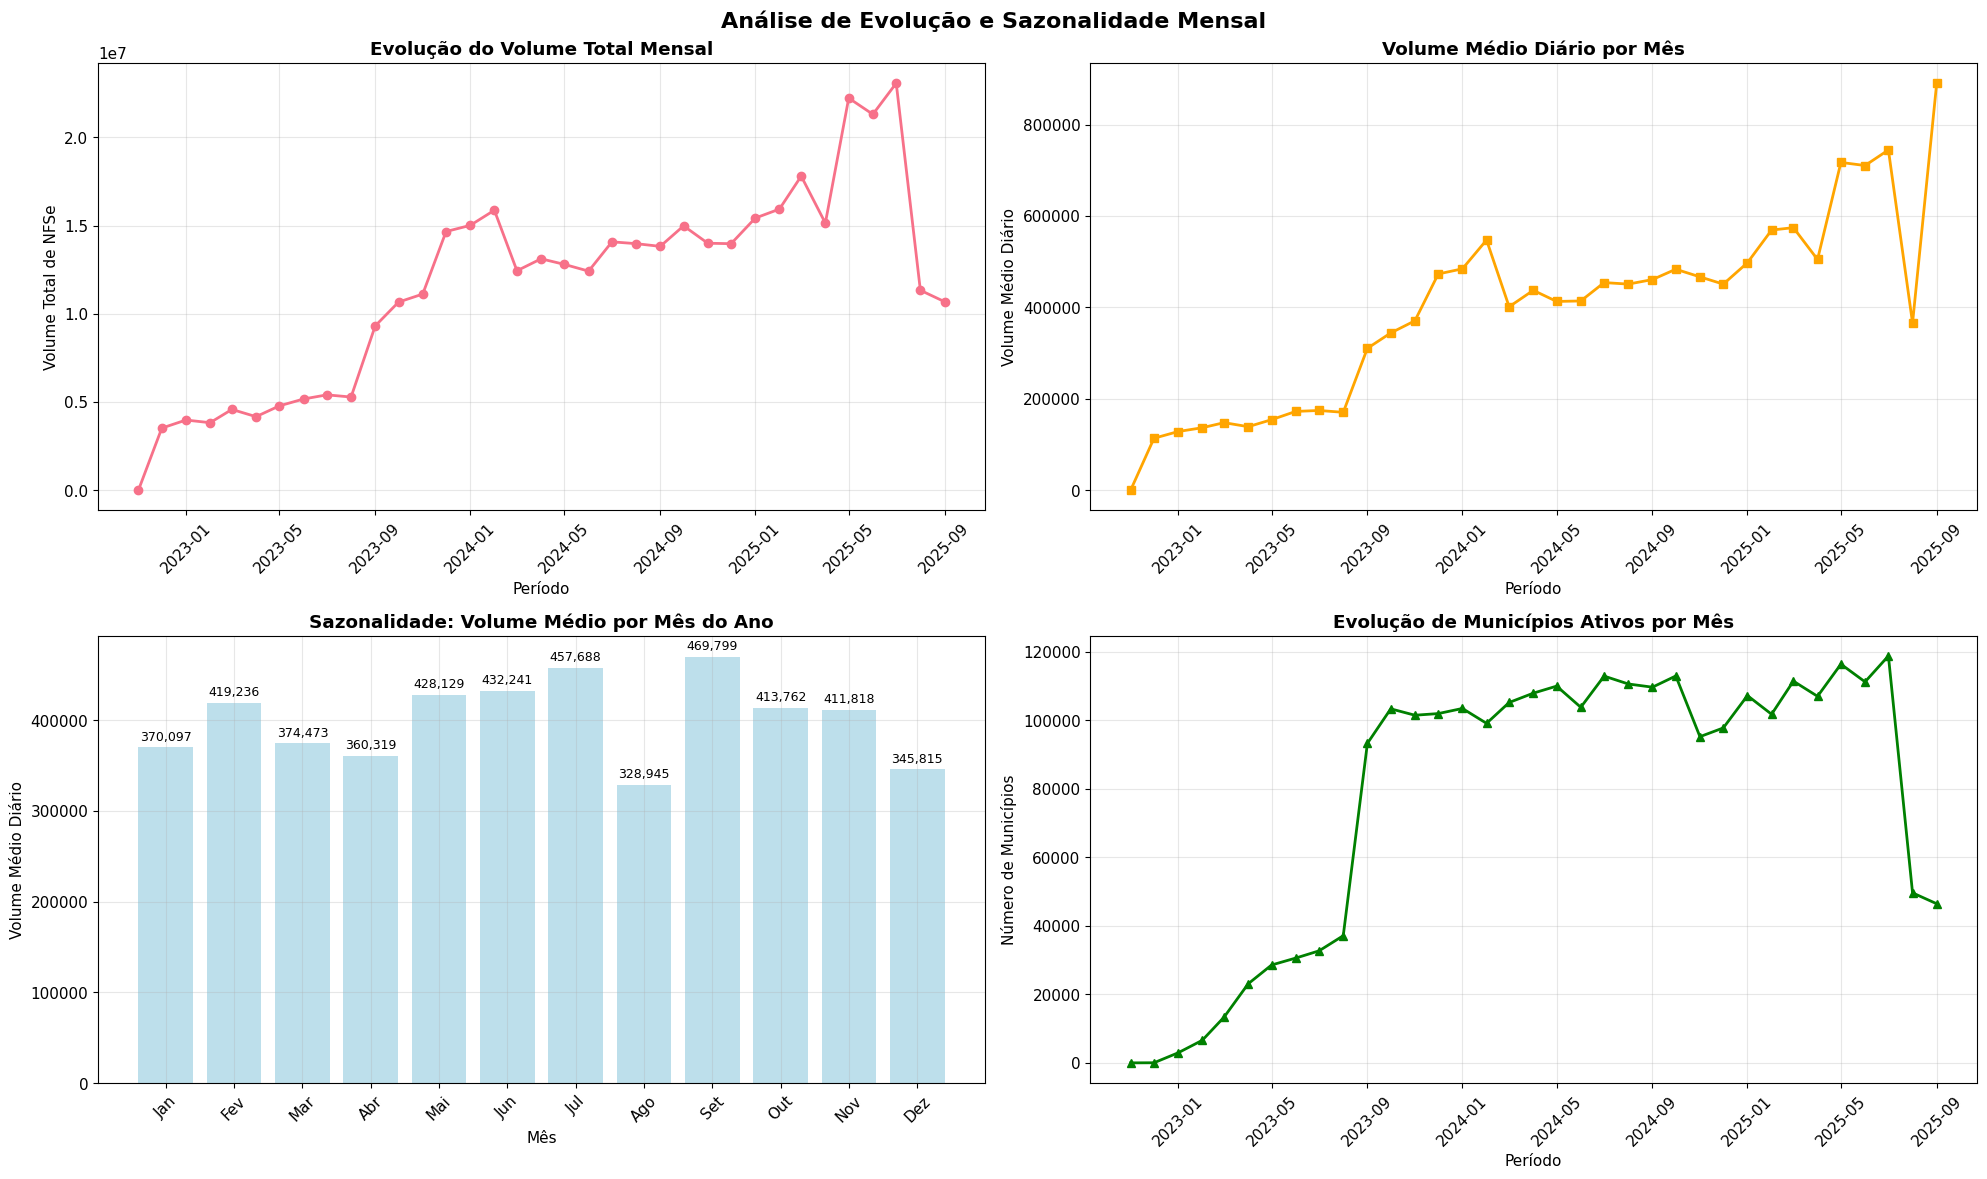


📊 SAZONALIDADE POR MÊS:
Mês com MAIOR volume: Set (469,799 NFSe/dia)
Mês com MENOR volume: Ago (328,945 NFSe/dia)
Diferença sazonal: 42.8%

📈 CRESCIMENTO:
Volume médio últimos 12 meses: 16,328,002 NFSe/mês
Volume médio primeiros 12 meses: 5,055,569 NFSe/mês
Taxa de crescimento: 223.0%


In [3]:
# Análise mensal detalhada
print("=== 📈 ANÁLISE DE EVOLUÇÃO MENSAL ===")

# Agregação por mês
evolucao_mensal = df.groupby(['ano', 'mes']).agg({
    'total_nfse_processadas': ['sum', 'mean', 'std'],
    'municipios_diferentes': 'sum',
    'prestadores_diferentes': 'sum',
    'data_processamento': 'count'  # dias no mês
}).round(0)

evolucao_mensal.columns = ['volume_total', 'volume_medio_dia', 'desvio_padrao', 
                          'municipios', 'prestadores', 'dias_mes']
evolucao_mensal = evolucao_mensal.reset_index()
evolucao_mensal['mes_ano_str'] = evolucao_mensal['ano'].astype(str) + '-' + evolucao_mensal['mes'].astype(str).str.zfill(2)
evolucao_mensal['periodo'] = pd.to_datetime(evolucao_mensal['mes_ano_str'])

# Análise de sazonalidade por mês do ano
sazonalidade_mes = df.groupby('mes').agg({
    'total_nfse_processadas': ['mean', 'median', 'std']
}).round(0)
sazonalidade_mes.columns = ['media', 'mediana', 'desvio']
sazonalidade_mes = sazonalidade_mes.reset_index()
sazonalidade_mes['mes_nome'] = sazonalidade_mes['mes'].map({i+1: meses_pt[i] for i in range(12)})

# Visualizações
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Análise de Evolução e Sazonalidade Mensal', fontsize=16, fontweight='bold')

# 1. Evolução temporal mensal
axes[0,0].plot(evolucao_mensal['periodo'], evolucao_mensal['volume_total'], 
              marker='o', linewidth=2, markersize=6)
axes[0,0].set_title('Evolução do Volume Total Mensal', fontweight='bold')
axes[0,0].set_xlabel('Período')
axes[0,0].set_ylabel('Volume Total de NFSe')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Volume médio diário por mês
axes[0,1].plot(evolucao_mensal['periodo'], evolucao_mensal['volume_medio_dia'], 
              marker='s', linewidth=2, markersize=6, color='orange')
axes[0,1].set_title('Volume Médio Diário por Mês', fontweight='bold')
axes[0,1].set_xlabel('Período')
axes[0,1].set_ylabel('Volume Médio Diário')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Sazonalidade por mês do ano
bars = axes[1,0].bar(sazonalidade_mes['mes_nome'], sazonalidade_mes['media'], 
                    color='lightblue', alpha=0.8)
axes[1,0].set_title('Sazonalidade: Volume Médio por Mês do Ano', fontweight='bold')
axes[1,0].set_xlabel('Mês')
axes[1,0].set_ylabel('Volume Médio Diário')
axes[1,0].tick_params(axis='x', rotation=45)

# Adicionar valores nas barras
for bar, valor in zip(bars, sazonalidade_mes['media']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(sazonalidade_mes['media']) * 0.01,
                  f'{valor:,.0f}', ha='center', va='bottom', fontsize=9)

# 4. Crescimento de municípios ativos
axes[1,1].plot(evolucao_mensal['periodo'], evolucao_mensal['municipios'], 
              marker='^', linewidth=2, markersize=6, color='green')
axes[1,1].set_title('Evolução de Municípios Ativos por Mês', fontweight='bold')
axes[1,1].set_xlabel('Período')
axes[1,1].set_ylabel('Número de Municípios')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Estatísticas mensais
print("\n📊 SAZONALIDADE POR MÊS:")
sazonalidade_ordenada = sazonalidade_mes.sort_values('media', ascending=False)
print(f"Mês com MAIOR volume: {sazonalidade_ordenada.iloc[0]['mes_nome']} ({sazonalidade_ordenada.iloc[0]['media']:,.0f} NFSe/dia)")
print(f"Mês com MENOR volume: {sazonalidade_ordenada.iloc[-1]['mes_nome']} ({sazonalidade_ordenada.iloc[-1]['media']:,.0f} NFSe/dia)")
print(f"Diferença sazonal: {(sazonalidade_ordenada.iloc[0]['media'] / sazonalidade_ordenada.iloc[-1]['media'] - 1) * 100:.1f}%")

# Crescimento recente
crescimento_12_meses = evolucao_mensal.tail(12)['volume_total'].mean()
crescimento_anterior = evolucao_mensal.head(12)['volume_total'].mean()
print(f"\n📈 CRESCIMENTO:")
print(f"Volume médio últimos 12 meses: {crescimento_12_meses:,.0f} NFSe/mês")
print(f"Volume médio primeiros 12 meses: {crescimento_anterior:,.0f} NFSe/mês")
print(f"Taxa de crescimento: {(crescimento_12_meses / crescimento_anterior - 1) * 100:.1f}%")


## 2. Análise de Padrões Semanais
### Identificação de dias críticos para dimensionamento de recursos


=== 📅 ANÁLISE DE PADRÕES SEMANAIS ===


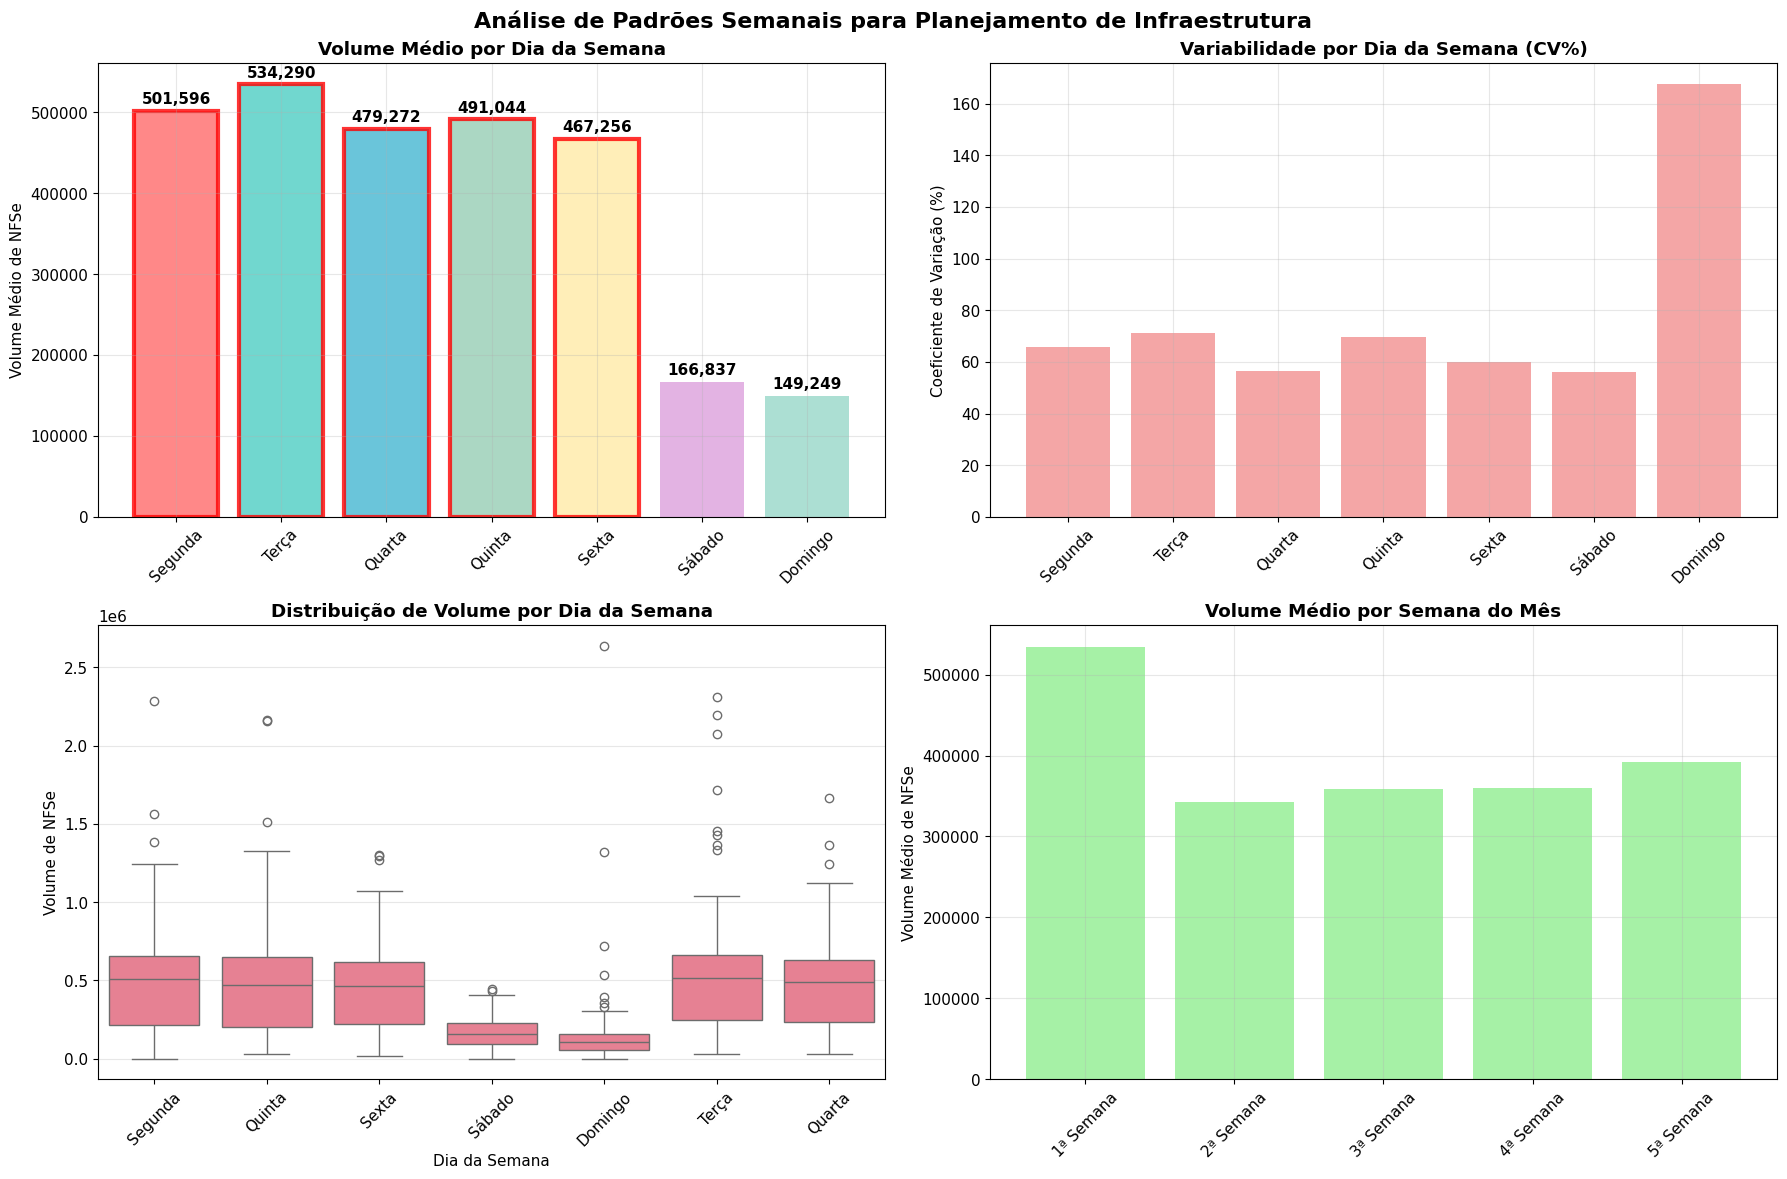


🏗️ INSIGHTS PARA INFRAESTRUTURA:
📊 Dia de MAIOR carga: Terça (534,290 NFSe/dia)
📊 Dia de MENOR carga: Domingo (149,249 NFSe/dia)
📊 Diferença de carga: 258.0%

💡 RECOMENDAÇÕES:
• Capacidade base: 398,506 NFSe/dia
• Fator de pico (Terça): 1.34x
• Capacidade recomendada: 641,148 NFSe/dia (com 20% margem)

⚠️ DIAS MAIS VARIÁVEIS (requerem monitoramento):
• Domingo: CV = 167.4%
• Terça: CV = 71.0%
• Quinta: CV = 69.5%


In [4]:
# Análise semanal detalhada
print("=== 📅 ANÁLISE DE PADRÕES SEMANAIS ===")

# Padrões por dia da semana
padroes_semanais = df.groupby('dia_semana').agg({
    'total_nfse_processadas': ['count', 'mean', 'median', 'std', 'min', 'max'],
    'municipios_diferentes': 'mean'
}).round(0)

padroes_semanais.columns = ['dias_total', 'volume_medio', 'volume_mediano', 'desvio_padrao', 
                           'volume_min', 'volume_max', 'municipios_medio']
padroes_semanais = padroes_semanais.reset_index()
padroes_semanais['dia_nome'] = padroes_semanais['dia_semana'].map({i: dias_pt[i] for i in range(7)})
padroes_semanais['variabilidade'] = (padroes_semanais['desvio_padrao'] / padroes_semanais['volume_medio'] * 100).round(1)

# Análise por semana do mês (primeira, segunda, terceira, quarta semana)
df['semana_mes'] = ((df['dia'] - 1) // 7) + 1
padroes_semana_mes = df.groupby('semana_mes').agg({
    'total_nfse_processadas': ['mean', 'std']
}).round(0)
padroes_semana_mes.columns = ['volume_medio', 'desvio_padrao']
padroes_semana_mes = padroes_semana_mes.reset_index()

# Visualizações
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análise de Padrões Semanais para Planejamento de Infraestrutura', fontsize=16, fontweight='bold')

# 1. Volume médio por dia da semana
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']
bars = axes[0,0].bar(padroes_semanais['dia_nome'], padroes_semanais['volume_medio'], 
                    color=colors, alpha=0.8)
axes[0,0].set_title('Volume Médio por Dia da Semana', fontweight='bold')
axes[0,0].set_ylabel('Volume Médio de NFSe')
axes[0,0].tick_params(axis='x', rotation=45)

# Adicionar valores e destacar picos
for i, (bar, valor) in enumerate(zip(bars, padroes_semanais['volume_medio'])):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(padroes_semanais['volume_medio']) * 0.01,
                  f'{valor:,.0f}', ha='center', va='bottom', fontweight='bold')
    # Destacar dias de pico (acima da média)
    if valor > padroes_semanais['volume_medio'].mean():
        bar.set_edgecolor('red')
        bar.set_linewidth(3)

# 2. Variabilidade por dia da semana
axes[0,1].bar(padroes_semanais['dia_nome'], padroes_semanais['variabilidade'], 
             color='lightcoral', alpha=0.7)
axes[0,1].set_title('Variabilidade por Dia da Semana (CV%)', fontweight='bold')
axes[0,1].set_ylabel('Coeficiente de Variação (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Box plot - distribuição por dia da semana
df_box = df[['dia_semana', 'total_nfse_processadas', 'dia_semana_nome']].copy()
sns.boxplot(data=df_box, x='dia_semana_nome', y='total_nfse_processadas', ax=axes[1,0])
axes[1,0].set_title('Distribuição de Volume por Dia da Semana', fontweight='bold')
axes[1,0].set_xlabel('Dia da Semana')
axes[1,0].set_ylabel('Volume de NFSe')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Padrão por semana do mês
axes[1,1].bar(['1ª Semana', '2ª Semana', '3ª Semana', '4ª Semana', '5ª Semana'][:len(padroes_semana_mes)], 
             padroes_semana_mes['volume_medio'], color='lightgreen', alpha=0.8)
axes[1,1].set_title('Volume Médio por Semana do Mês', fontweight='bold')
axes[1,1].set_ylabel('Volume Médio de NFSe')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Insights para infraestrutura
print("\n🏗️ INSIGHTS PARA INFRAESTRUTURA:")
dia_pico = padroes_semanais.loc[padroes_semanais['volume_medio'].idxmax()]
dia_baixo = padroes_semanais.loc[padroes_semanais['volume_medio'].idxmin()]

print(f"📊 Dia de MAIOR carga: {dia_pico['dia_nome']} ({dia_pico['volume_medio']:,.0f} NFSe/dia)")
print(f"📊 Dia de MENOR carga: {dia_baixo['dia_nome']} ({dia_baixo['volume_medio']:,.0f} NFSe/dia)")
print(f"📊 Diferença de carga: {(dia_pico['volume_medio'] / dia_baixo['volume_medio'] - 1) * 100:.1f}%")

# Recomendações de capacidade
fator_pico = dia_pico['volume_medio'] / padroes_semanais['volume_medio'].mean()
print(f"\n💡 RECOMENDAÇÕES:")
print(f"• Capacidade base: {padroes_semanais['volume_medio'].mean():,.0f} NFSe/dia")
print(f"• Fator de pico ({dia_pico['dia_nome']}): {fator_pico:.2f}x")
print(f"• Capacidade recomendada: {dia_pico['volume_medio'] * 1.2:,.0f} NFSe/dia (com 20% margem)")

# Dias mais variáveis (requerem monitoramento)
dias_variaveis = padroes_semanais.nlargest(3, 'variabilidade')
print(f"\n⚠️ DIAS MAIS VARIÁVEIS (requerem monitoramento):")
for _, dia in dias_variaveis.iterrows():
    print(f"• {dia['dia_nome']}: CV = {dia['variabilidade']:.1f}%")


## 3. Análise de Padrões Horários
### Identificação de horários de pico para dimensionamento de servidores


=== ⏰ ANÁLISE DE PADRÕES HORÁRIOS ===


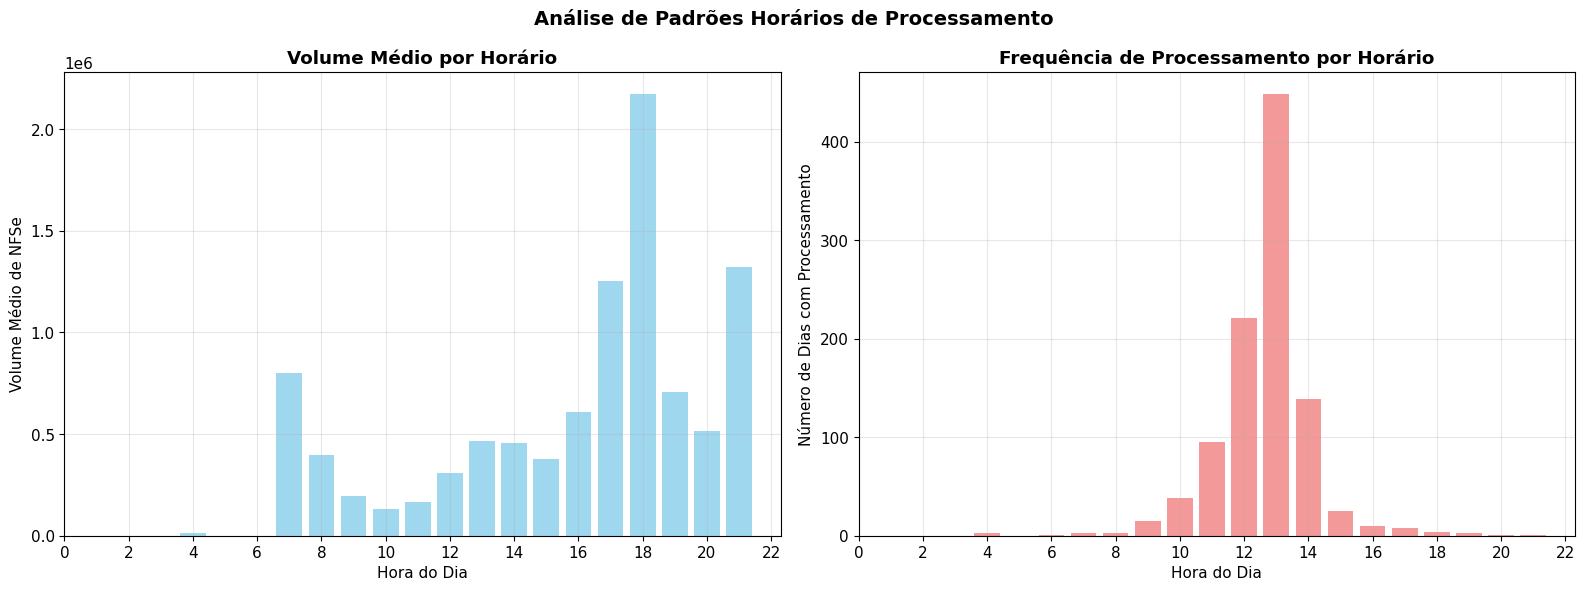


⏰ HORÁRIOS CRÍTICOS:
Horário de PICO: 18h (2,171,550 NFSe)
Horário de BAIXA: 6h (300 NFSe)

🕐 VOLUME MÉDIO POR PERÍODO:
• Madrugada (0-6h): 14,622 NFSe
• Manhã (6-12h): 282,544 NFSe
• Tarde (12-18h): 578,263 NFSe
• Noite (18-24h): 1,178,368 NFSe


In [5]:
# Análise horária (quando disponível)
print("=== ⏰ ANÁLISE DE PADRÕES HORÁRIOS ===")

if 'hora_media_processamento' in df.columns:
    # Filtrar apenas registros com hora válida
    df_com_hora = df[df['hora_media_processamento'].notna()].copy()
    
    if len(df_com_hora) > 0:
        # Padrões horários
        padroes_horarios = df_com_hora.groupby('hora_media_processamento').agg({
            'total_nfse_processadas': ['count', 'mean', 'sum']
        }).round(0)
        padroes_horarios.columns = ['dias_registrados', 'volume_medio', 'volume_total']
        padroes_horarios = padroes_horarios.reset_index()
        
        # Visualização horária
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Análise de Padrões Horários de Processamento', fontsize=14, fontweight='bold')
        
        # Volume por hora
        axes[0].bar(padroes_horarios['hora_media_processamento'], padroes_horarios['volume_medio'],
                   color='skyblue', alpha=0.8)
        axes[0].set_title('Volume Médio por Horário', fontweight='bold')
        axes[0].set_xlabel('Hora do Dia')
        axes[0].set_ylabel('Volume Médio de NFSe')
        axes[0].set_xticks(range(0, 24, 2))
        
        # Frequência de processamento por hora
        axes[1].bar(padroes_horarios['hora_media_processamento'], padroes_horarios['dias_registrados'],
                   color='lightcoral', alpha=0.8)
        axes[1].set_title('Frequência de Processamento por Horário', fontweight='bold')
        axes[1].set_xlabel('Hora do Dia')
        axes[1].set_ylabel('Número de Dias com Processamento')
        axes[1].set_xticks(range(0, 24, 2))
        
        plt.tight_layout()
        plt.show()
        
        # Identificar horários de pico
        hora_pico = padroes_horarios.loc[padroes_horarios['volume_medio'].idxmax()]
        hora_baixa = padroes_horarios.loc[padroes_horarios['volume_medio'].idxmin()]
        
        print(f"\n⏰ HORÁRIOS CRÍTICOS:")
        print(f"Horário de PICO: {int(hora_pico['hora_media_processamento'])}h ({hora_pico['volume_medio']:,.0f} NFSe)")
        print(f"Horário de BAIXA: {int(hora_baixa['hora_media_processamento'])}h ({hora_baixa['volume_medio']:,.0f} NFSe)")
        
        # Classificar períodos do dia
        periodos = {
            'Madrugada (0-6h)': padroes_horarios[padroes_horarios['hora_media_processamento'] < 6]['volume_medio'].mean(),
            'Manhã (6-12h)': padroes_horarios[(padroes_horarios['hora_media_processamento'] >= 6) & 
                                             (padroes_horarios['hora_media_processamento'] < 12)]['volume_medio'].mean(),
            'Tarde (12-18h)': padroes_horarios[(padroes_horarios['hora_media_processamento'] >= 12) & 
                                              (padroes_horarios['hora_media_processamento'] < 18)]['volume_medio'].mean(),
            'Noite (18-24h)': padroes_horarios[padroes_horarios['hora_media_processamento'] >= 18]['volume_medio'].mean()
        }
        
        print(f"\n🕐 VOLUME MÉDIO POR PERÍODO:")
        for periodo, volume in periodos.items():
            if not np.isnan(volume):
                print(f"• {periodo}: {volume:,.0f} NFSe")
    
    else:
        print("⚠️ Não há dados válidos de horário para análise")
else:
    print("⚠️ Coluna de horário não encontrada nos dados")
    
    # Análise alternativa baseada em padrões diários
    print("\n📊 ANÁLISE BASEADA EM PADRÕES DIÁRIOS:")
    
    # Simular padrões horários baseados em conhecimento comum
    horas_comerciais = list(range(8, 18))  # 8h às 17h
    volume_medio_dia = df['total_nfse_processadas'].mean()
    
    # Distribuição estimada (baseada em padrões típicos de sistemas administrativos)
    distribuicao_estimada = {
        'Horário Comercial (8-17h)': 0.75,  # 75% do volume
        'Horário Estendido (7-8h, 17-19h)': 0.15,  # 15% do volume
        'Fora do Horário (19-7h)': 0.10  # 10% do volume
    }
    
    print("📈 DISTRIBUIÇÃO ESTIMADA DO PROCESSAMENTO:")
    for periodo, percentual in distribuicao_estimada.items():
        volume_estimado = volume_medio_dia * percentual
        print(f"• {periodo}: {percentual*100:.0f}% (~{volume_estimado:,.0f} NFSe/dia)")


## 4. Análise de Tendências e Projeções para 2026
### Preparação para obrigatoriedade nacional de compartilhamento


=== 📈 ANÁLISE DE TENDÊNCIAS E PROJEÇÕES 2026 ===


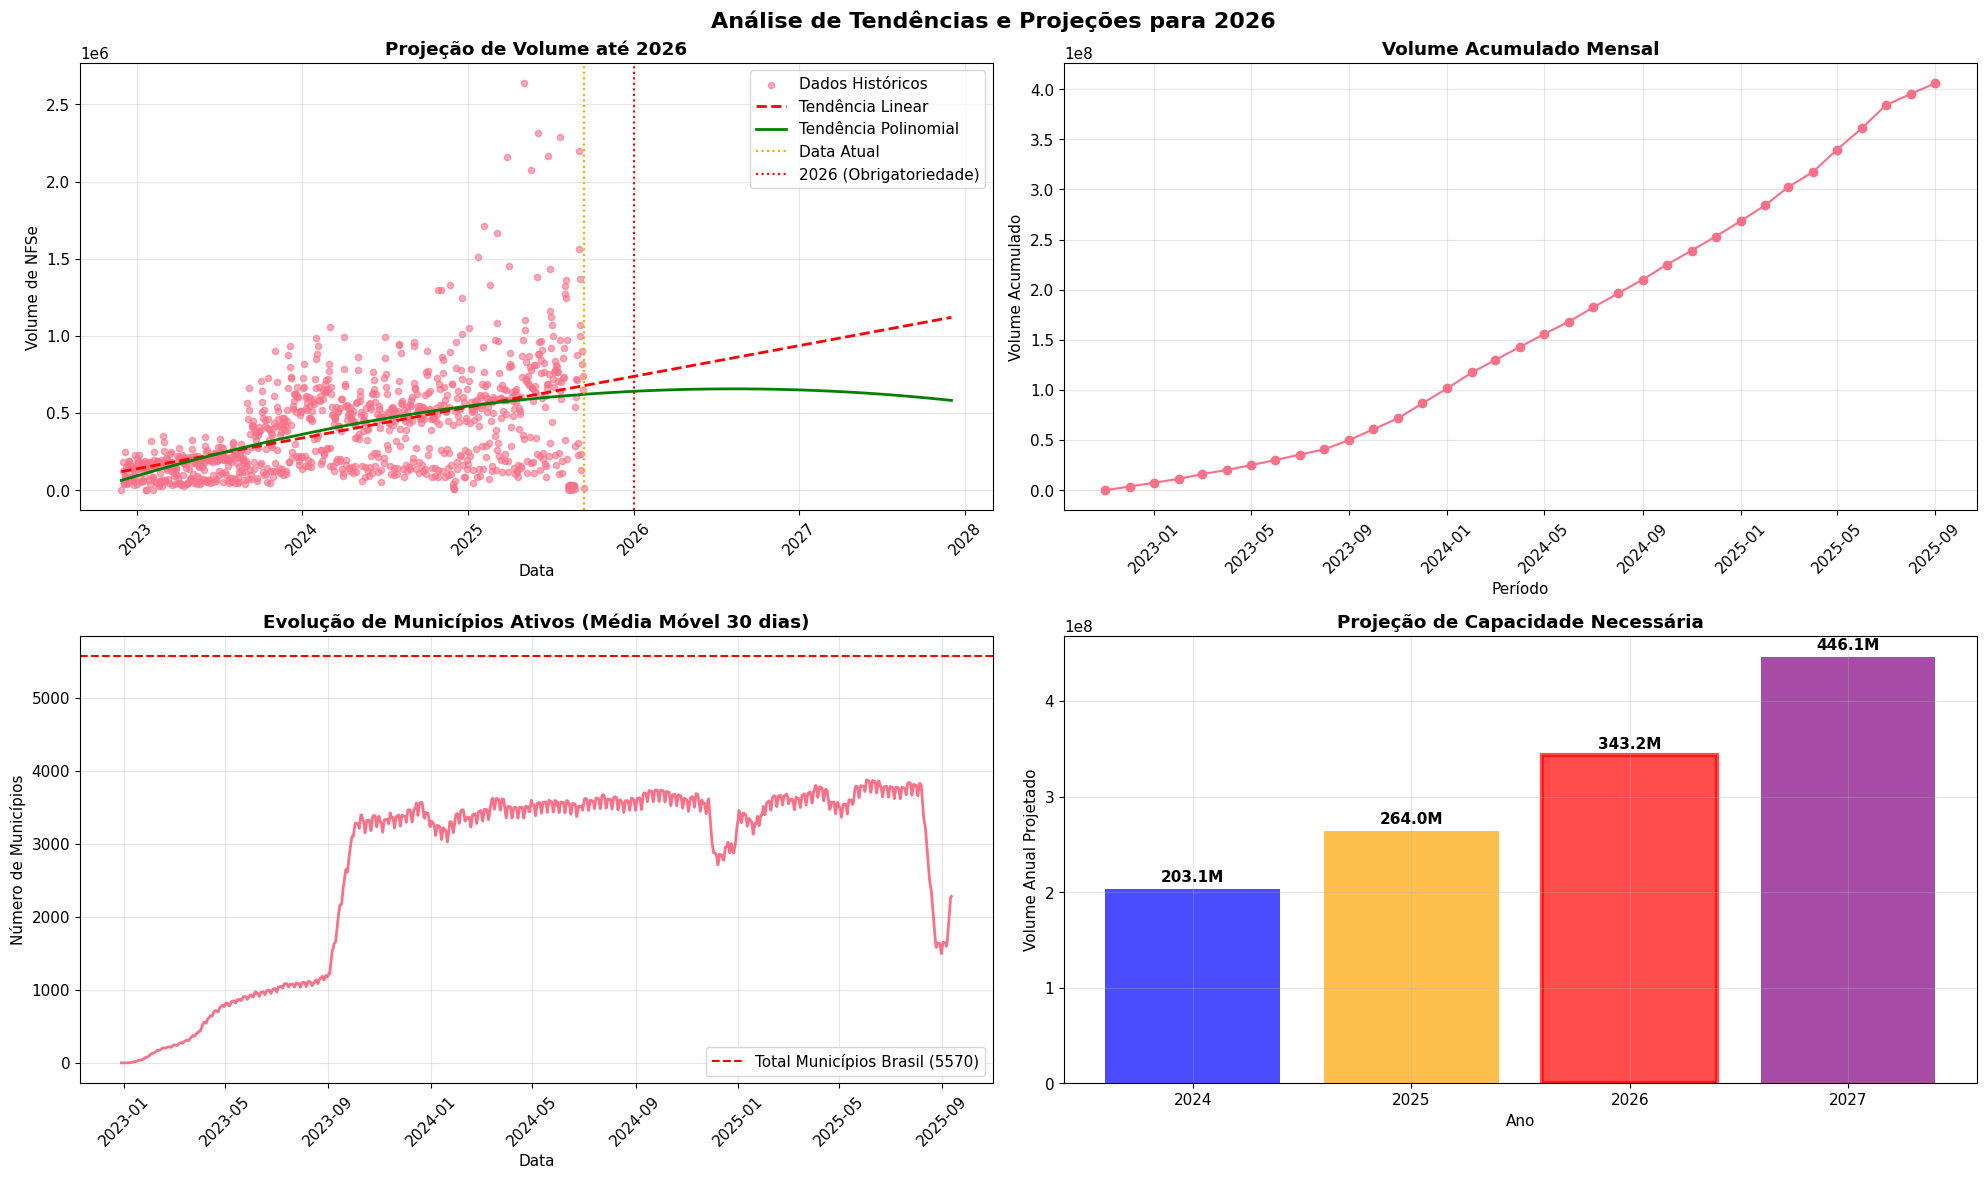


🎯 PROJEÇÕES PARA 2026:
Volume atual (último ano): 203,064,698 NFSe
Taxa de crescimento histórica: 30.0% ao ano
Projeção linear para 2026: 936,184 NFSe/dia
Projeção polinomial para 2026: 649,564 NFSe/dia

📊 IMPACTO DA OBRIGATORIEDADE 2026:
Municípios ativos atualmente: 4927 (88.5% do total)
Municípios que precisarão aderir: 643
Fator de multiplicação estimado: 1.1x
Volume estimado 2026 (com obrigatoriedade): 387,966,089 NFSe/ano
Volume diário médio estimado 2026: 1,062,921 NFSe/dia

🏗️ RECOMENDAÇÕES DE INFRAESTRUTURA PARA 2026:
Capacidade diária recomendada: 1,594,381 NFSe/dia
Capacidade de pico recomendada: 3,985,953 NFSe/dia
Crescimento necessário vs. atual: 4.0x


In [6]:
# Análise de tendências e projeções
print("=== 📈 ANÁLISE DE TENDÊNCIAS E PROJEÇÕES 2026 ===")

# Preparar dados para regressão
df['dias_desde_inicio'] = (df['data_processamento'] - df['data_processamento'].min()).dt.days

# Modelos de tendência
X = df['dias_desde_inicio'].values.reshape(-1, 1)
y = df['total_nfse_processadas'].values

# Regressão linear
modelo_linear = LinearRegression()
modelo_linear.fit(X, y)

# Regressão polinomial (grau 2)
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)
modelo_poly = LinearRegression()
modelo_poly.fit(X_poly, y)

# Gerar projeções até 2026
data_atual = df['data_processamento'].max()
data_2026 = pd.to_datetime('2026-12-31')
dias_ate_2026 = (data_2026 - df['data_processamento'].min()).days

# Dados para projeção
dias_projecao = np.arange(0, dias_ate_2026 + 365, 30)  # Mensal
X_projecao = dias_projecao.reshape(-1, 1)
X_projecao_poly = poly_features.transform(X_projecao)

# Fazer projeções
y_pred_linear = modelo_linear.predict(X_projecao)
y_pred_poly = modelo_poly.predict(X_projecao_poly)

# Converter dias para datas
datas_projecao = [df['data_processamento'].min() + timedelta(days=int(d)) for d in dias_projecao]

# Análise de crescimento de municípios
total_municipios_brasil = 5570  # Total de municípios brasileiros
municipios_atuais = df['municipios_diferentes'].max()
taxa_crescimento_municipios = (municipios_atuais / df['municipios_diferentes'].iloc[0]) ** (1 / len(df['ano'].unique())) - 1

# Visualizações
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Análise de Tendências e Projeções para 2026', fontsize=16, fontweight='bold')

# 1. Tendência histórica e projeções
axes[0,0].scatter(df['data_processamento'], df['total_nfse_processadas'], 
                 alpha=0.6, s=20, label='Dados Históricos')
axes[0,0].plot(datas_projecao, y_pred_linear, 'r--', linewidth=2, label='Tendência Linear')
axes[0,0].plot(datas_projecao, y_pred_poly, 'g-', linewidth=2, label='Tendência Polinomial')
axes[0,0].axvline(data_atual, color='orange', linestyle=':', label='Data Atual')
axes[0,0].axvline(pd.to_datetime('2026-01-01'), color='red', linestyle=':', label='2026 (Obrigatoriedade)')
axes[0,0].set_title('Projeção de Volume até 2026', fontweight='bold')
axes[0,0].set_xlabel('Data')
axes[0,0].set_ylabel('Volume de NFSe')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Crescimento mensal acumulado
volume_mensal = df.groupby(df['data_processamento'].dt.to_period('M'))['total_nfse_processadas'].sum().cumsum()
axes[0,1].plot(volume_mensal.index.to_timestamp(), volume_mensal.values, marker='o')
axes[0,1].set_title('Volume Acumulado Mensal', fontweight='bold')
axes[0,1].set_xlabel('Período')
axes[0,1].set_ylabel('Volume Acumulado')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Crescimento de municípios
municipios_tempo = df.groupby('data_processamento')['municipios_diferentes'].max().rolling(30).mean()
axes[1,0].plot(municipios_tempo.index, municipios_tempo.values, linewidth=2)
axes[1,0].axhline(total_municipios_brasil, color='red', linestyle='--', 
                 label=f'Total Municípios Brasil ({total_municipios_brasil})')
axes[1,0].set_title('Evolução de Municípios Ativos (Média Móvel 30 dias)', fontweight='bold')
axes[1,0].set_xlabel('Data')
axes[1,0].set_ylabel('Número de Municípios')
axes[1,0].legend()
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Projeção de capacidade necessária
anos_projecao = [2024, 2025, 2026, 2027]
capacidade_atual = df['total_nfse_processadas'].tail(365).sum()  # Último ano
crescimento_anual = 0.3  # 30% ao ano (estimativa conservadora)

capacidades_projetadas = [capacidade_atual * (1 + crescimento_anual) ** (ano - 2024) for ano in anos_projecao]

bars = axes[1,1].bar([str(ano) for ano in anos_projecao], capacidades_projetadas, 
                    color=['blue', 'orange', 'red', 'purple'], alpha=0.7)
axes[1,1].set_title('Projeção de Capacidade Necessária', fontweight='bold')
axes[1,1].set_xlabel('Ano')
axes[1,1].set_ylabel('Volume Anual Projetado')

# Destacar 2026
bars[2].set_edgecolor('red')
bars[2].set_linewidth(3)

# Adicionar valores
for bar, valor in zip(bars, capacidades_projetadas):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(capacidades_projetadas) * 0.01,
                  f'{valor/1e6:.1f}M', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Cálculos e projeções
crescimento_historico = (df['total_nfse_processadas'].tail(365).mean() / df['total_nfse_processadas'].head(365).mean()) ** (1/len(df['ano'].unique())) - 1

# Projeções para 2026
volume_2026_linear = modelo_linear.predict([[dias_ate_2026]])[0]
volume_2026_poly = modelo_poly.predict(poly_features.transform([[dias_ate_2026]]))[0]

print(f"\n🎯 PROJEÇÕES PARA 2026:")
print(f"Volume atual (último ano): {capacidade_atual:,.0f} NFSe")
print(f"Taxa de crescimento histórica: {crescimento_historico*100:.1f}% ao ano")
print(f"Projeção linear para 2026: {volume_2026_linear:,.0f} NFSe/dia")
print(f"Projeção polinomial para 2026: {max(0, volume_2026_poly):,.0f} NFSe/dia")

# Estimativa do impacto da obrigatoriedade
percentual_municipios_ativos = (municipios_atuais / total_municipios_brasil) * 100
fator_crescimento_2026 = total_municipios_brasil / municipios_atuais

print(f"\n📊 IMPACTO DA OBRIGATORIEDADE 2026:")
print(f"Municípios ativos atualmente: {municipios_atuais} ({percentual_municipios_ativos:.1f}% do total)")
print(f"Municípios que precisarão aderir: {total_municipios_brasil - municipios_atuais}")
print(f"Fator de multiplicação estimado: {fator_crescimento_2026:.1f}x")

volume_2026_estimado = capacidade_atual * fator_crescimento_2026 * (1 + crescimento_anual) ** 2
print(f"Volume estimado 2026 (com obrigatoriedade): {volume_2026_estimado:,.0f} NFSe/ano")
print(f"Volume diário médio estimado 2026: {volume_2026_estimado/365:,.0f} NFSe/dia")

# Recomendações de infraestrutura
fator_seguranca = 1.5  # 50% de margem de segurança
capacidade_recomendada_2026 = volume_2026_estimado / 365 * fator_seguranca

print(f"\n🏗️ RECOMENDAÇÕES DE INFRAESTRUTURA PARA 2026:")
print(f"Capacidade diária recomendada: {capacidade_recomendada_2026:,.0f} NFSe/dia")
print(f"Capacidade de pico recomendada: {capacidade_recomendada_2026 * 2.5:,.0f} NFSe/dia")
print(f"Crescimento necessário vs. atual: {(capacidade_recomendada_2026 / df['total_nfse_processadas'].mean()):.1f}x")
